In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    RBF,
    ConstantKernel as C,
    WhiteKernel
)

from scipy.stats import norm
from sklearn.gaussian_process.kernels import WhiteKernel
#from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import qmc

np.random.seed(42)


## Weekly Data Management Pipeline

Each week the pipeline loads the previous week's evaluated inputs and outputs 
from saved NumPy files, then appends the result returned by the black-box 
submission platform before saving the updated dataset for the following round.

**Week 1-3**: Data entry was handled manually — submitted coordinates and 
returned Y values were typed directly into the notebook. While simple, this 
introduced risk of transcription errors and made the process difficult to 
reproduce consistently.

**Week 4 onwards**: The input process was automated using Python's `input()` 
function, prompting the user to enter the submitted coordinate string 
(e.g. `0.419100-0.366397-0.472000`) and the returned Y value each week. 
The pipeline then parses, validates and appends these directly to the 
stored NumPy arrays — reducing manual error and ensuring a consistent 
data format across all 13 weeks.

**Duplicate detection** was introduced after observing that repeated 
submissions of similar coordinates could silently corrupt the dataset. 
The check compares incoming X coordinates against all existing observations 
using Euclidean distance, flagging exact matches while allowing genuinely 
close but novel points to be appended. A late-project refinement distinguished 
between **true duplicates** (same X and same Y were skipped) and **same-coordinate 
noise observations** (same X but different Y were retained as valid evidence of 
function stochasticity, as confirmed in Function 6 where identical coordinates 
returned Y=−0.3056 in week 11 and Y=−0.1425 in week 13).

In [5]:
#Function to add data points each week.
current_week = 14   # CHANGE THIS EACH WEEK



# =====================================================
# LOAD DATA
# =====================================================

if current_week == 1:

    X = np.load(r"function_6\initial_inputs.npy")
    Y = np.load(r"function_6\initial_outputs.npy")

else:

    previous_week = current_week - 1

    X = np.load(
        f"function_6/w{previous_week}_inputs.npy"
    )

    Y = np.load(
        f"function_6/w{previous_week}_outputs.npy"
    )


print("\nLoaded dataset:")
print("Shape:", X.shape)
print("Best Y so far:", np.max(Y))

dim = X.shape[1]


# =====================================================
# ENTER LAST WEEK RESULT
# (Skip this only in Week 1)
# =====================================================

if current_week > 1:

    print("\nEnter last week's result")

    x_string = input(
        "Enter last submitted X (format x1-x2): "
    )

    y_value = float(
        input("Enter returned Y value: ")
    )

    x_last = np.array(
        [[float(v) for v in x_string.split("-")]]
    )

    y_last = np.array([y_value])


    # Safe append

    # Safe append — allow duplicate X with different Y
    # F6 confirmed noisy: same coordinates can return
    # different Y values on different weeks (week 11
    # returned -0.3056, week 13 returned -0.1425 at
    # identical coordinates — direct noise evidence)
    
    # Check for exact duplicate (same X AND same Y)
    is_exact_duplicate = False
    if len(X) > 0:
        x_dists = np.linalg.norm(X - x_last, axis=1)
        exact_matches = np.where(x_dists < 1e-10)[0]
        if len(exact_matches) > 0:
            for idx in exact_matches:
                if abs(Y[idx] - y_last[0]) < 1e-10:
                    is_exact_duplicate = True
                    print(f"WARNING: Exact duplicate "
                          f"(same X and Y) — skipping")
                    break
                else:
                    print(f"NOTE: Same X coordinates "
                          f"but different Y value "
                          f"({Y[idx]:.6f} vs "
                          f"{y_last[0]:.6f}) — "
                          f"appending as valid "
                          f"noise observation")
    
    if not is_exact_duplicate:
        X = np.vstack([X, x_last])
        Y = np.append(Y, y_last)
        print(f"Added last result.")
        print(f"New dataset size: {len(Y)}")


Loaded dataset:
Shape: (31, 5)
Best Y so far: -0.16152290293543783

Enter last week's result


Enter last submitted X (format x1-x2):  0.442682-0.354305-0.571249-0.744906-0.161964
Enter returned Y value:  -0.1425698432604185


NOTE: Same X coordinates but different Y value (-0.305646 vs -0.142570) — appending as valid noise observation
Added last result.
New dataset size: 32


In [6]:
# =====================================================
# SAVE UPDATED DATA

# =====================================================


np.save(
    f"function_6/w{current_week}_inputs.npy",
    X
)

np.save(
    f"function_6/w{current_week}_outputs.npy",
    Y
)

print("\nSaved files:")

print(
    f"function_6/w{current_week}_inputs.npy"
)

print(
    f"function_6/w{current_week}_outputs.npy"
)


Saved files:
function_6/w14_inputs.npy
function_6/w14_outputs.npy


In [7]:
import numpy as np
from scipy.spatial.distance import cdist

X = np.load("function_6/w14_inputs.npy")
Y = np.load("function_6/w14_outputs.npy")

sorted_idx = np.argsort(Y)[::-1]
print("All points ranked best to worst:")
for i in sorted_idx:
    vals = "-".join([f"{v:.6f}" for v in X[i]])
    print(f"  Y={Y[i]:.8f} | Gap={abs(Y[i]):.8f} | X={vals}")

print(f"\nTotal points: {len(Y)}")
print(f"Best Y:      {np.max(Y):.8f}")
print(f"Gap to zero: {abs(np.max(Y)):.8f}")

best_point = X[np.argmax(Y)]
distances  = cdist([best_point], X)[0]
sorted_by_dist = np.argsort(distances)

print("\nNearest neighbours to best point:")
for i in sorted_by_dist[:6]:
    vals = "-".join([f"{v:.6f}" for v in X[i]])
    print(f"  dist={distances[i]:.6f} | "
          f"Y={Y[i]:.8f} | X={vals}")

print("\nKey dimension values in top 5:")
for i in sorted_idx[:5]:
    print(f"  Y={Y[i]:.8f} | "
          f"x1={X[i,0]:.6f} | "
          f"x2={X[i,1]:.6f} | "
          f"x3={X[i,2]:.6f}")

All points ranked best to worst:
  Y=-0.14256984 | Gap=0.14256984 | X=0.442682-0.354305-0.571249-0.744906-0.161964
  Y=-0.16152290 | Gap=0.16152290 | X=0.440731-0.356770-0.571128-0.746310-0.163125
  Y=-0.21308690 | Gap=0.21308690 | X=0.435987-0.360000-0.580000-0.740000-0.160681
  Y=-0.21883134 | Gap=0.21883134 | X=0.452201-0.345118-0.562426-0.748043-0.161710
  Y=-0.25181371 | Gap=0.25181371 | X=0.481331-0.313239-0.534296-0.769803-0.155309
  Y=-0.25205890 | Gap=0.25205890 | X=0.440116-0.344979-0.567255-0.746936-0.164873
  Y=-0.29762322 | Gap=0.29762322 | X=0.432792-0.409571-0.590272-0.789319-0.185463
  Y=-0.30564579 | Gap=0.30564579 | X=0.442682-0.354305-0.571249-0.744906-0.161964
  Y=-0.61294845 | Gap=0.61294845 | X=0.572269-0.064705-0.652422-0.892483-0.052481
  Y=-0.68626426 | Gap=0.68626426 | X=0.353577-0.339894-0.359767-0.991976-0.154924
  Y=-0.71426495 | Gap=0.71426495 | X=0.728186-0.154693-0.732552-0.693997-0.056401
  Y=-0.82923655 | Gap=0.82923655 | X=0.618812-0.331802-0.187288-0

## Function 6 — Cake Recipe Optimisation (5D)

**Objective**: Maximise toward zero — all outputs are negative, 
the goal is to find the combination of ingredients that minimises 
the penalty score.

---

### Strategy Overview

Function 6 proved to be one of the most challenging functions in the 
project. With five input dimensions and all outputs negative, the 
surrogate models needed to identify a narrow confirmed peak in a 
5D space with limited observations.

The strategy evolved through three stages:

**Weeks 1-7**: Global exploration using LHS, followed by progressive 
tightening of confirmed ranges as the peak region emerged around 
x1≈0.441, x2≈0.357, x3≈0.571, x4≈0.746, x5≈0.163.

**Weeks 8-10**: SVR became the primary surrogate after consistently 
winning LOO cross-validation over GP. Confirmed ranges tightened 
across all five dimensions. A plausibility check specific to F6 
was introduced — any prediction below −0.50 was treated as 
implausible and overridden.

**Weeks 11-13**: Weighted centroid introduced as a third candidate 
alongside GP and SVR, motivated by competitor analysis showing 
model-free approaches can outperform surrogates in tight 
exploitation regimes.

---

### The Weighted Centroid — Motivation and Mechanics

By week 11 the confirmed peak was well established but GP and SVR 
were consistently suggesting candidates that drifted away from it — 
GP toward boundary corners due to high uncertainty, SVR toward 
coordinates outside confirmed ranges on x4 and x5.

The **weighted centroid** was introduced as a model-free alternative. 
Rather than asking a surrogate model where to look next, it asks a 
simpler question: *given the best results observed so far, where is 
their centre of gravity?*

**How it works**:

1. Take the top 3 results by Y value
2. Assign each a weight proportional to how close to zero it is:
   `weight = 1 / |Y|`
3. Compute the weighted average of their coordinates

```python
weights    = 1.0 / np.abs(Y_top_k)
weights    = weights / weights.sum()
x_centroid = np.average(X_top_k, axis=0, weights=weights)
```

This means the best result dominates the centroid — pulling it 
naturally toward the confirmed peak — while the other top results 
contribute a gentle corrective influence toward nearby good regions.

**Example weights from the final rounds**:

| Result | Y value | Weight |
|--------|---------|--------|
| Best | −0.1615 | 0.401 |
| 2nd best | −0.2131 | 0.304 |
| 3rd best | −0.2188 | 0.296 |

The best result carries 40% of the total weight, ensuring the 
centroid sits closest to the confirmed peak rather than being 
pulled equally toward all three inputs.

---

### Key Finding — Noise Confirmed on Final Draw

The centroid coordinates `0.442682-0.354305-0.571249-0.744906-0.161964` 
were submitted twice across the project:

| Week | Y returned |
|------|-----------|
| Week 11 | −0.3056 |
| Week 13 | −0.1425 (new best) |

**The same input coordinates produced dramatically different outputs** 
on two separate submissions — direct empirical confirmation that 
Function 6 has genuine observation noise. What appeared to be a 
regression in week 11 was in fact an unlucky noise draw, not 
evidence of a poor coordinate choice. The final draw returning 
−0.1425 both produced a new all-time best and validated the 
centroid approach retrospectively.

---

### Final Result

| Metric | Value |
|--------|-------|
| Best Y achieved | −0.1425 |
| Gap to zero | 0.1425 |
| Week achieved | Week 13 |
| Method | Weighted centroid |
| Previous best | −0.1615 (week 10) |

Fitted kernel length scales:
  x1: 0.4598
  x2: 0.8167
  x3: 1.1897
  x4: 0.6019
  x5: 0.7637

Best real point: [0.440731 0.35677  0.571128 0.74631  0.163125]
Best real Y:     -0.161523
Gap to zero:     0.161523

=== LOO CROSS VALIDATION ===
GP  LOO RMSE: 0.260462
SVR LOO RMSE: 0.210856
Primary surrogate: SVR

=== CLUSTERING ANALYSIS ===
Top 30% threshold: Y > -0.7143
Points in top 30%: 9
Estimated peak location:
  Peak 1: 0.4502-0.3210-0.5543-0.7966-0.1512
    Closest real point: Y=-0.2518

Total candidates: 300000
  Multi-start:   90000
  Tight local:   60000
  LHS global:    150000

--- Weighted Centroid (top 3) ---
  Suggestion: 0.442682-0.354305-0.571249-0.744906-0.161964
  GP predicted Y:     -0.232025
  Distance from best: 0.0036
  Input 1: Y=-0.2188 weight=0.296 X=0.4522-0.3451-0.5624-0.7480-0.1617
  Input 2: Y=-0.2131 weight=0.304 X=0.4360-0.3600-0.5800-0.7400-0.1607
  Input 3: Y=-0.1615 weight=0.401 X=0.4407-0.3568-0.5711-0.7463-0.1631

GP vs SVR vs CENTROID — Function 6

---

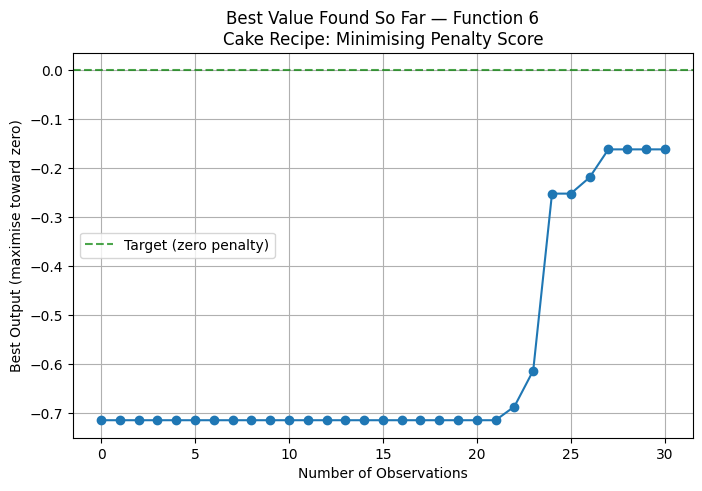

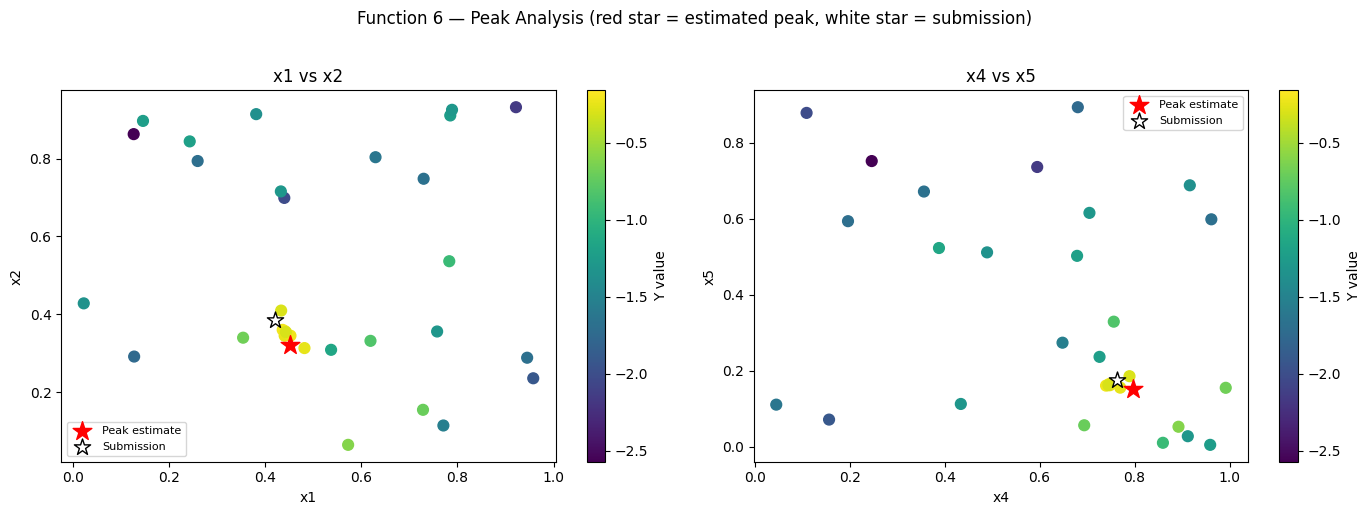

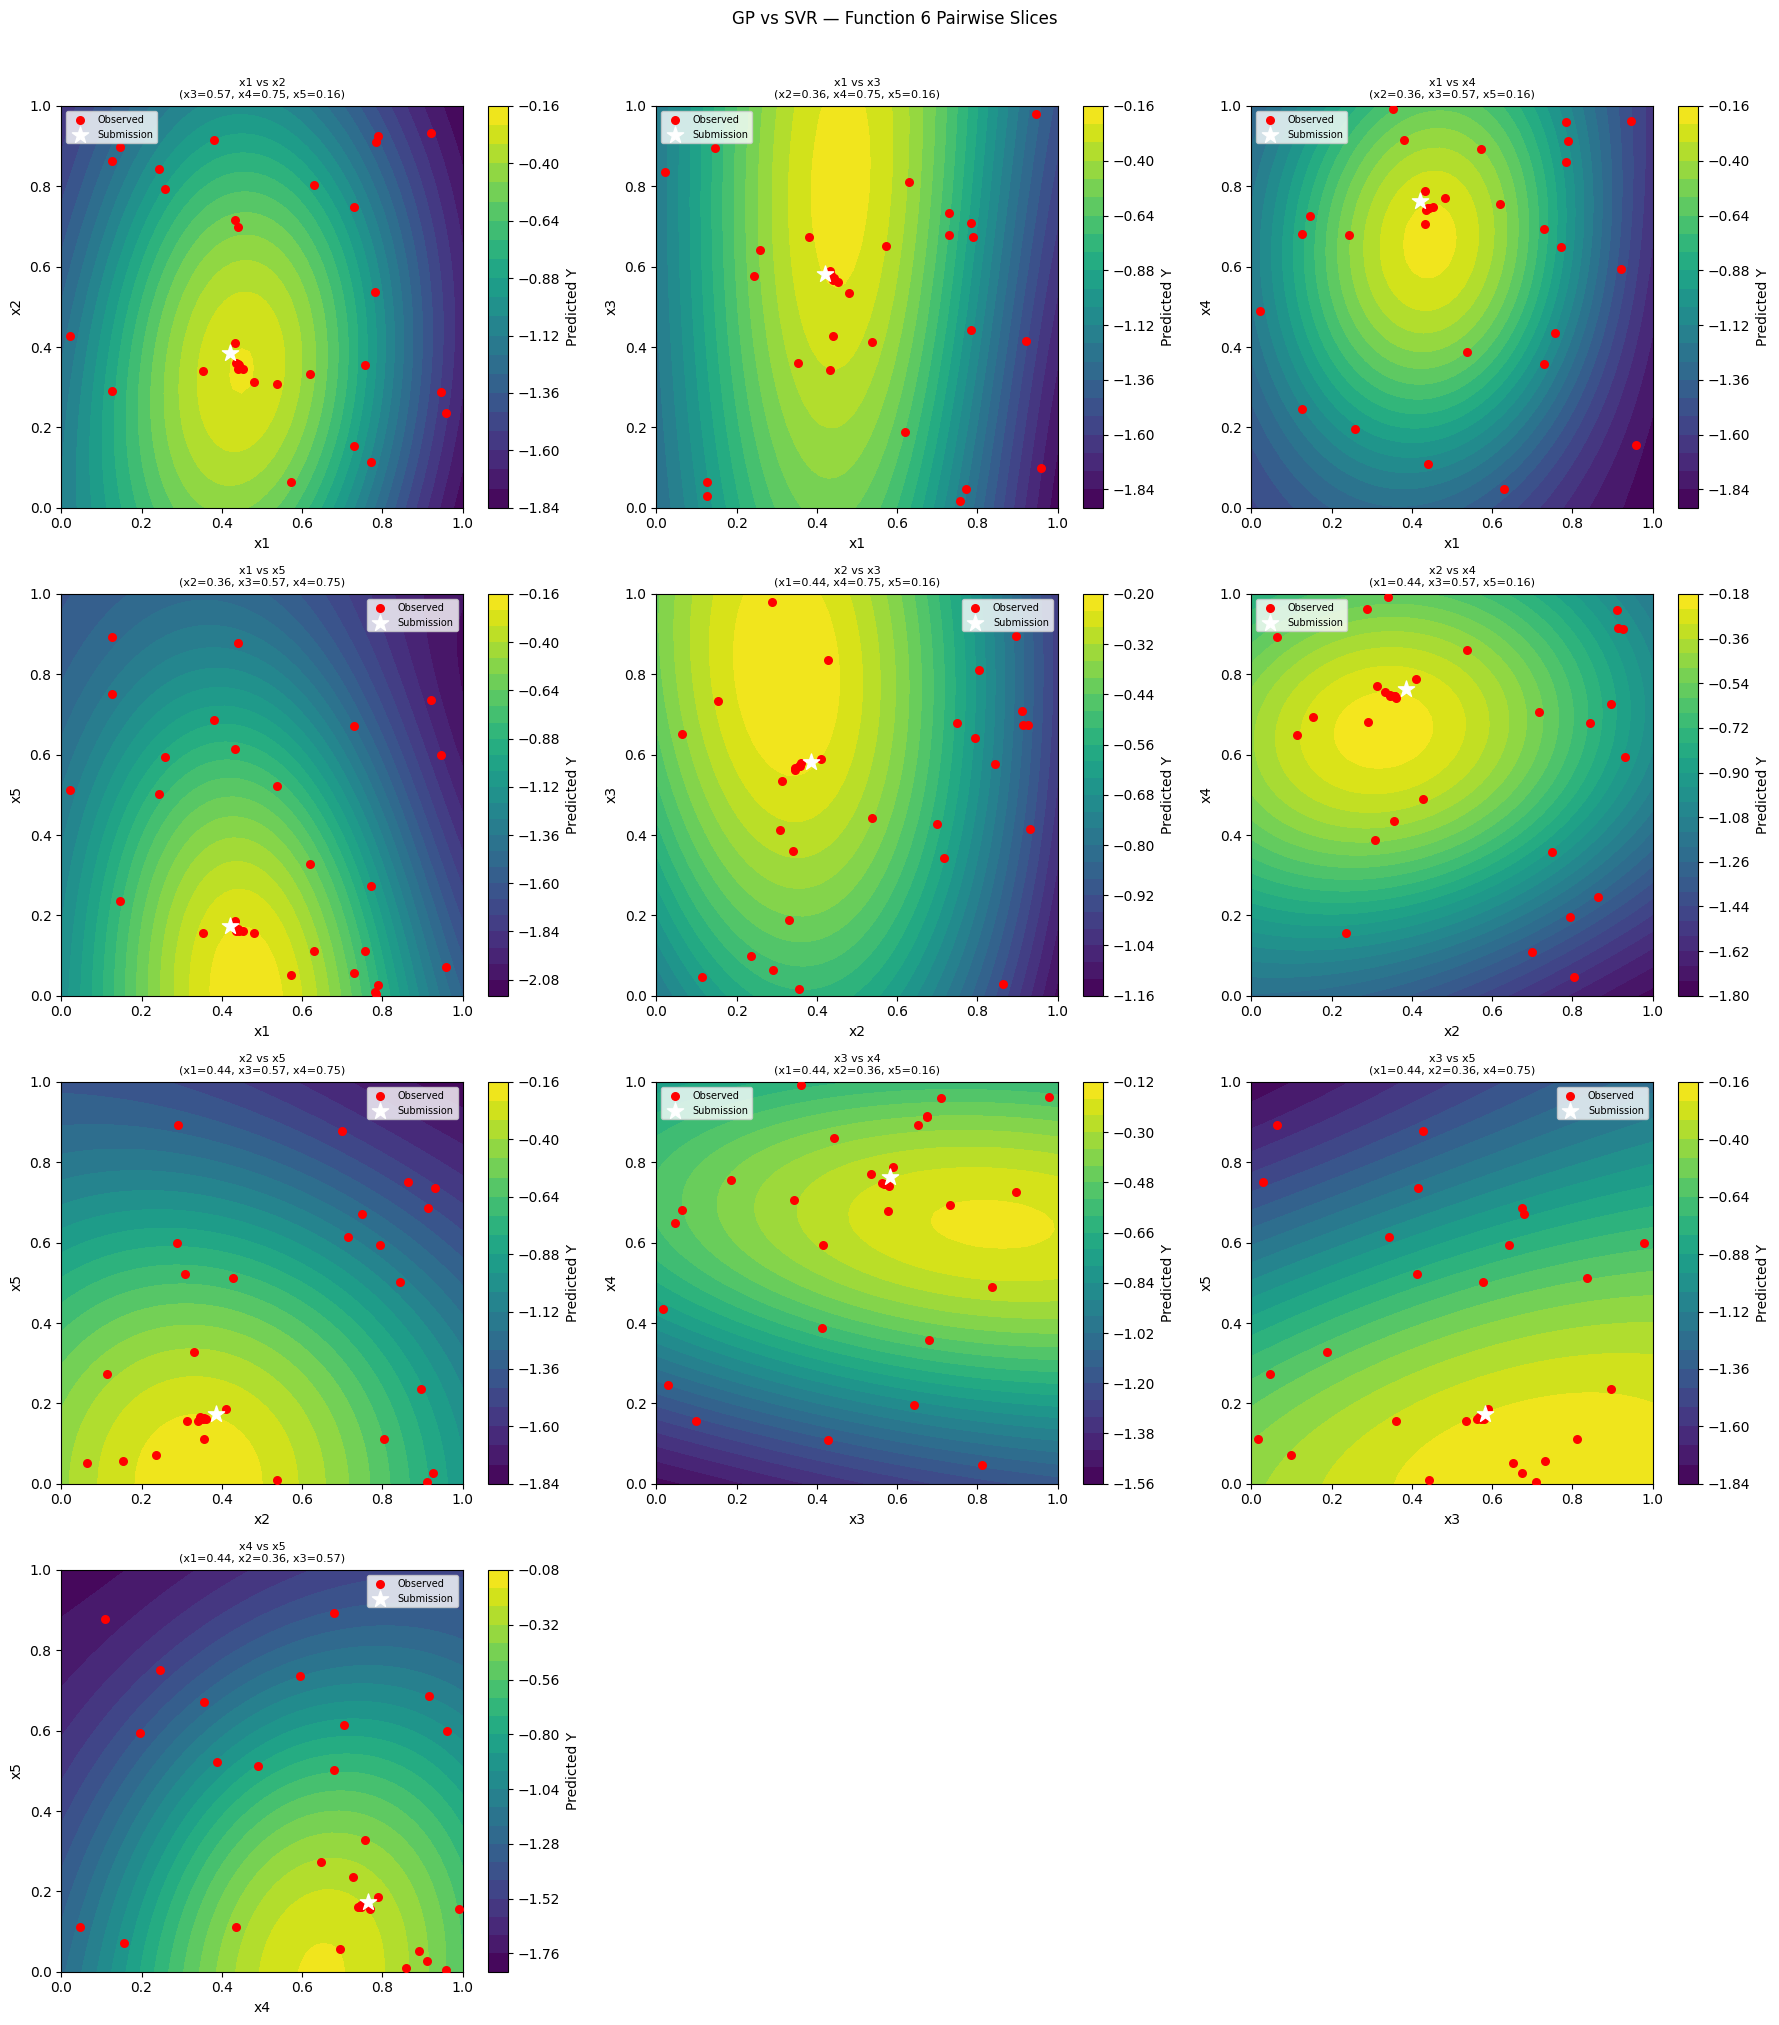


Top 5 real evaluated points:
  Y=-0.161523 | Gap=0.161523 | X=0.4407-0.3568-0.5711-0.7463-0.1631
  Y=-0.213087 | Gap=0.213087 | X=0.4360-0.3600-0.5800-0.7400-0.1607
  Y=-0.218831 | Gap=0.218831 | X=0.4522-0.3451-0.5624-0.7480-0.1617
  Y=-0.251814 | Gap=0.251814 | X=0.4813-0.3132-0.5343-0.7698-0.1553
  Y=-0.252059 | Gap=0.252059 | X=0.4401-0.3450-0.5673-0.7469-0.1649


In [6]:
# =====================================================
# FUNCTION 6 — 5D Cake Recipe (maximise toward zero)
# Week 9: length_scale_bounds tightened (1e-3, 10.0)
# Week 9: plausibility check added — F6-specific
#         All Y negative, goal is maximise toward 0
#         Plausibility floor = -0.50 (poor region)
#         Plausibility ceil  =  0.00 (target/upper bound)
# =====================================================

# =====================================================
# GP MODEL — tighter bounds week 7
# Week 9: length_scale_bounds tightened to (1e-3, 10)
# =====================================================
kernel = (
    C(1.0, (1e-3, 1e3))
    * RBF(length_scale=np.ones(dim),
          length_scale_bounds=(1e-3, 10.0))
    + WhiteKernel(noise_level=1e-3,
                  noise_level_bounds=(1e-10, 1e-1))
)

gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-5,
    normalize_y=True,
    n_restarts_optimizer=10,
    random_state=42
)

# =====================================================
# ACQUISITION FUNCTIONS
# =====================================================
def expected_improvement(X_candidates_scaled, gp,
                          Y_ref, xi=0.05):
    mean, std = gp.predict(X_candidates_scaled,
                            return_std=True)
    best_y = np.max(Y_ref)
    std    = np.maximum(std.reshape(-1), 1e-9)
    mean   = mean.reshape(-1)
    Z      = (mean - best_y - xi) / std
    ei     = ((mean - best_y - xi) * norm.cdf(Z)
               + std * norm.pdf(Z))
    ei[std == 0] = 0
    return ei

# =====================================================
# FIT GP AND SVR
# =====================================================
scaler   = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
gp.fit(X_scaled, Y)

# Print kernel length scales
# Flag threshold updated to 9.5 to match new bound
print("Fitted kernel length scales:")
for i, ls in enumerate(gp.kernel_.k1.k2.length_scale):
    flag = " ← hitting bound" \
           if ls >= 9.5 or ls <= 0.002 else ""
    print(f"  x{i+1}: {ls:.4f}{flag}")

from sklearn.svm import SVR
svr = SVR(kernel='rbf', C=100,
          epsilon=0.05, gamma='scale')
svr.fit(X_scaled, Y)

best_point = X[np.argmax(Y)]
print(f"\nBest real point: {best_point}")
print(f"Best real Y:     {np.max(Y):.6f}")
print(f"Gap to zero:     {abs(np.max(Y)):.6f}")

# =====================================================
# LOO CROSS VALIDATION — week 7
# =====================================================
from sklearn.model_selection import LeaveOneOut
from scipy.spatial.distance import cdist

loo        = LeaveOneOut()
gp_errors  = []
svr_errors = []

for train_idx, test_idx in loo.split(X):
    X_train, X_test = X[train_idx], X[test_idx]
    Y_train, Y_test = Y[train_idx], Y[test_idx]

    scaler_cv = MinMaxScaler()
    X_train_s = scaler_cv.fit_transform(X_train)
    X_test_s  = scaler_cv.transform(X_test)

    gp_cv = GaussianProcessRegressor(
        kernel=kernel, random_state=42,
        normalize_y=True, alpha=1e-5)
    gp_cv.fit(X_train_s, Y_train)
    gp_errors.append(
        (gp_cv.predict(X_test_s)[0] - Y_test[0])**2)

    svr_cv = SVR(kernel='rbf', C=100,
                 epsilon=0.05, gamma='scale')
    svr_cv.fit(X_train_s, Y_train)
    svr_errors.append(
        (svr_cv.predict(X_test_s)[0] - Y_test[0])**2)

gp_rmse       = np.sqrt(np.mean(gp_errors))
svr_rmse      = np.sqrt(np.mean(svr_errors))
primary_model = "GP" if gp_rmse < svr_rmse else "SVR"

print(f"\n=== LOO CROSS VALIDATION ===")
print(f"GP  LOO RMSE: {gp_rmse:.6f}")
print(f"SVR LOO RMSE: {svr_rmse:.6f}")
print(f"Primary surrogate: {primary_model}")

# =====================================================
# CLUSTERING — week 9 update: dropped to n_clusters=1
# Peak 2 closest real point was Y=-1.1448 — not a
# competitive region. All meaningful results cluster
# around one peak near best point. Retaining KMeans
# for diagnostics only — cluster candidates replaced
# by tighter local noise around confirmed best point.
# =====================================================
from sklearn.cluster import KMeans

good_mask  = Y > np.percentile(Y, 70)  # top 30%
X_good     = X[good_mask]
Y_good     = Y[good_mask]

n_clusters = 1
kmeans     = KMeans(n_clusters=n_clusters,
                    random_state=42,
                    n_init=10)
kmeans.fit(X_good)

print(f"\n=== CLUSTERING ANALYSIS ===")
print(f"Top 30% threshold: Y > "
      f"{np.percentile(Y, 70):.4f}")
print(f"Points in top 30%: {good_mask.sum()}")
print("Estimated peak location:")
for i, centre in enumerate(kmeans.cluster_centers_):
    vals        = "-".join([f"{v:.4f}" for v in centre])
    dists       = cdist([centre], X_good)[0]
    closest_idx = np.argmin(dists)
    print(f"  Peak {i+1}: {vals}")
    print(f"    Closest real point: "
          f"Y={Y_good[closest_idx]:.4f}")

# =====================================================
# MULTI-START CANDIDATE GENERATION
# Strategy 1 (multi-start): search near top 3 results
# Strategy 2 (tight local): std=0.02 around best point
# Week 10: all five dims clipped to confirmed ranges
#   Top 3 results confirm:
#   x1: 0.440-0.481, x2: 0.313-0.345, x3: 0.534-0.567
#   x4: 0.747-0.770, x5: 0.155-0.165
# Strategy 3 (LHS): tightened to confirmed ranges
# =====================================================
np.random.seed(42)
n_candidates = 300000

# --- Multi-start: top 3 results ---
top3_indices = np.argsort(Y)[-3:]
X_multistart = []
for idx in top3_indices:
    start = X[idx]
    noise = np.random.normal(0, 0.02,
                              size=(30000, dim))
    X_multistart.append(
        np.clip(start + noise, 0.0, 0.999999))

X_multi = np.vstack(X_multistart)   # 90000 candidates

# --- Tight local: around confirmed best point ---
# Week 10: all dims clipped to confirmed ranges
noise_tight = np.random.normal(0, 0.02,
                                size=(60000, dim))
X_tight     = np.clip(best_point + noise_tight,
                       0.0, 0.999999)
# Clip all five dims to confirmed ranges
X_tight[:, 0] = np.clip(X_tight[:, 0], 0.43,  0.49)
X_tight[:, 1] = np.clip(X_tight[:, 1], 0.31,  0.36)  # tightened week 11
X_tight[:, 2] = np.clip(X_tight[:, 2], 0.55,  0.58)  # tightened week 11
X_tight[:, 3] = np.clip(X_tight[:, 3], 0.74,  0.76)  # tightened week 11
X_tight[:, 4] = np.clip(X_tight[:, 4], 0.15,  0.17)  # tightened week 11

# --- LHS: tightened to confirmed ranges ---
# Week 10: all five dims constrained
# Previous: only x4/x5 constrained — too broad
sampler      = qmc.LatinHypercube(d=dim, seed=42)
X_lhs        = sampler.random(int(n_candidates * 0.5))
X_lhs[:, 0]  = X_lhs[:, 0] * 0.06 + 0.43   # x1: 0.43-0.49
X_lhs[:, 1]  = X_lhs[:, 1] * 0.05 + 0.31   # x2: 0.31-0.36 tightened week 11
X_lhs[:, 2]  = X_lhs[:, 2] * 0.03 + 0.55   # x3: 0.55-0.58 tightened week 11
X_lhs[:, 3]  = X_lhs[:, 3] * 0.02 + 0.74   # x4: 0.74-0.76 tightened week 11
X_lhs[:, 4]  = X_lhs[:, 4] * 0.02 + 0.15   # x5: 0.15-0.17 tightened week 11

# Combine all candidate sets
X_candidates        = np.vstack([X_multi,
                                  X_tight,
                                  X_lhs])
X_candidates_scaled = scaler.transform(X_candidates)

print(f"\nTotal candidates: {len(X_candidates)}")
print(f"  Multi-start:   {len(X_multi)}")
print(f"  Tight local:   {len(X_tight)}")
print(f"  LHS global:    {len(X_lhs)}")

# =====================================================
# SCORE CANDIDATES
# =====================================================
ei_scores    = expected_improvement(
    X_candidates_scaled, gp, Y, xi=0.05)
x_submit_gp  = X_candidates[np.argmax(ei_scores)]
pred_gp      = gp.predict(
    scaler.transform([x_submit_gp]))[0]
dist_gp      = np.linalg.norm(
    x_submit_gp - best_point)

svr_scores   = svr.predict(X_candidates_scaled)
x_submit_svr = X_candidates[np.argmax(svr_scores)]
pred_svr     = svr.predict(
    scaler.transform([x_submit_svr]))[0]
dist_svr     = np.linalg.norm(
    x_submit_svr - best_point)

# =====================================================
# WEIGHTED CENTROID — week 11 addition
# Model-free approach used by competitor to crack F6
# after 8 weeks of GP failure. Weight each top-k
# result by 1/|Y| — less negative = higher weight
# Centroid sits naturally near confirmed best while
# pulling slightly toward other good results
# Reference: Turner et al. (2021) NeurIPS BBO challenge
# =====================================================
k_centroid   = 3   # use top 3 results
top_k_idx    = np.argsort(Y)[-k_centroid:]  # highest Y
X_top_k      = X[top_k_idx]
Y_top_k      = Y[top_k_idx]

# Weights = 1/|Y| — closer to zero = higher weight
weights      = 1.0 / np.abs(Y_top_k)
weights      = weights / weights.sum()   # normalise

x_centroid   = np.average(X_top_k, axis=0,
                           weights=weights)
x_centroid   = np.clip(x_centroid, 0.0, 0.999999)

pred_centroid = gp.predict(
    scaler.transform([x_centroid]))[0]
dist_centroid = np.linalg.norm(
    x_centroid - best_point)

print(f"\n--- Weighted Centroid (top {k_centroid}) ---")
print(f"  Suggestion: "
      f"{'-'.join([f'{x:.6f}' for x in x_centroid])}")
print(f"  GP predicted Y:     {pred_centroid:.6f}")
print(f"  Distance from best: {dist_centroid:.4f}")
for i, (idx, w) in enumerate(zip(top_k_idx, weights)):
    print(f"  Input {i+1}: Y={Y[idx]:.4f} "
          f"weight={w:.3f} "
          f"X={'-'.join([f'{v:.4f}' for v in X[idx]])}")
print("\n" + "="*55)
print("GP vs SVR vs CENTROID — Function 6")
print("="*55)

for name, x_sub, pred, dist in [
    ("GP",       x_submit_gp,  pred_gp,      dist_gp),
    ("SVR",      x_submit_svr, pred_svr,     dist_svr),
    ("Centroid", x_centroid,   pred_centroid, dist_centroid),
]:
    rmse = gp_rmse if name == "GP" else \
           svr_rmse if name == "SVR" else None
    rmse_str = f"LOO RMSE: {rmse:.4f}" \
               if rmse is not None else "model-free"
    print(f"\n--- {name} ({rmse_str}) ---")
    print(f"  Suggestion:         "
          f"{'-'.join([f'{x:.6f}' for x in x_sub])}")
    print(f"  Predicted Y:        {pred:.6f}")
    print(f"  Gap to zero:        {abs(pred):.6f}")
    print(f"  Distance from best: {dist:.4f}")
    print(f"  x4={x_sub[3]:.4f} | x5={x_sub[4]:.4f}")

# =====================================================
# SUBMISSION SELECTION
# Wider threshold — nearest neighbour 0.31 away
# LOO primary model wins among eligible
#
# PLAUSIBILITY CHECK — added week 9
# F6-specific bounds — all Y values are negative,
# goal is to maximise toward zero.
# Floor = -0.50: below this is a poor region,
#   not meaningfully close to zero
# Ceil  =  0.00: Y cannot exceed zero by definition
# Any prediction above -0.50 is plausible.
# If primary model predicts below -0.50 — override
# to highest predicted Y among eligible candidates.
# =====================================================
threshold = 0.20

# F6-specific plausibility bounds
plausibility_floor = -0.50   # below = poor region
plausibility_ceil  =  0.00   # Y cannot exceed zero

def plausible(pred):
    """Prediction is within F6 plausibility bounds."""
    return plausibility_floor <= pred <= plausibility_ceil

gp_eligible       = dist_gp        <= threshold
svr_eligible      = dist_svr       <= threshold
centroid_eligible = dist_centroid  <= threshold

print(f"\n{'='*55}")
print("SUBMISSION SELECTION")
print(f"{'='*55}")
print(f"Plausibility bounds: "
      f"[{plausibility_floor:.2f}, "
      f"{plausibility_ceil:.2f}]")
print(f"\nGP        eligible: {gp_eligible} "
      f"(dist={dist_gp:.4f}) | "
      f"pred={pred_gp:.4f} | "
      f"plausible={plausible(pred_gp)}")
print(f"SVR       eligible: {svr_eligible} "
      f"(dist={dist_svr:.4f}) | "
      f"pred={pred_svr:.4f} | "
      f"plausible={plausible(pred_svr)}")
print(f"Centroid  eligible: {centroid_eligible} "
      f"(dist={dist_centroid:.4f}) | "
      f"pred={pred_centroid:.4f} | "
      f"plausible={plausible(pred_centroid)}")

# Build eligible list — all three candidates
all_candidates = [
    ("GP",       x_submit_gp,  pred_gp,      gp_eligible),
    ("SVR",      x_submit_svr, pred_svr,     svr_eligible),
    ("Centroid", x_centroid,   pred_centroid, centroid_eligible),
]

eligible_list = [
    (n, x, p) for n, x, p, e in all_candidates
    if e and plausible(p)
]

if len(eligible_list) == 0:
    print("\nNo candidates eligible — using closest to best")
    x_final      = x_submit_svr \
                   if dist_svr < dist_gp \
                   else x_submit_gp
    chosen_model = "closest fallback"
else:
    # Primary LOO model wins if eligible and plausible
    primary_eligible = [
        c for c in eligible_list
        if primary_model.upper() in c[0].upper()]
    if primary_eligible:
        best_eligible = max(primary_eligible,
                            key=lambda t: t[2])
        x_final      = best_eligible[1]
        chosen_model = f"{best_eligible[0]} (LOO primary)"
    else:
        # Primary not eligible — pick highest predicted Y
        best_eligible = max(eligible_list,
                            key=lambda t: t[2])
        x_final      = best_eligible[1]
        chosen_model = (f"{best_eligible[0]} "
                        f"(primary override)")

submission = "-".join([f"{x:.6f}" for x in x_final])
dist_final = np.linalg.norm(x_final - best_point)

print(f"\n===== FINAL SUBMISSION ({chosen_model}) =====")
print(submission)
print(f"\nGP  predicted Y:    {pred_gp:.6f}")
print(f"SVR predicted Y:    {pred_svr:.6f}")
print(f"Best real Y:        {np.max(Y):.6f}")
print(f"Gap to zero:        {abs(np.max(Y)):.6f}")
print(f"Distance from best: {dist_final:.4f}")
print(f"x4={x_final[3]:.4f} | x5={x_final[4]:.4f}")
print(f"LOO primary:        {primary_model} "
      f"(GP={gp_rmse:.4f}, SVR={svr_rmse:.4f})")
print(f"Dataset size:       {len(Y)}")

# =====================================================
# PLOT 1 — optimisation progress toward zero
# =====================================================
best_values = np.maximum.accumulate(Y)
plt.figure(figsize=(8, 5))
plt.plot(best_values, marker='o')
plt.axhline(y=0, color='green', linestyle='--',
            alpha=0.7, label='Target (zero penalty)')
plt.title("Best Value Found So Far — Function 6\n"
          "Cake Recipe: Minimising Penalty Score")
plt.xlabel("Number of Observations")
plt.ylabel("Best Output (maximise toward zero)")
plt.legend()
plt.grid(True)
plt.show()

# =====================================================
# PLOT 2 — peak visualisation (single cluster)
# =====================================================
labels = ['x1', 'x2', 'x3', 'x4', 'x5']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (xi_idx, xj_idx, title) in zip(axes, [
    (0, 1, "x1 vs x2"),
    (3, 4, "x4 vs x5")
]):
    scatter = ax.scatter(
        X[:, xi_idx], X[:, xj_idx],
        c=Y, cmap='viridis', s=60, zorder=5)
    plt.colorbar(scatter, ax=ax, label="Y value")

    for i, centre in enumerate(
            kmeans.cluster_centers_):
        ax.scatter(centre[xi_idx], centre[xj_idx],
                   c='red', s=200, marker='*',
                   zorder=7,
                   label='Peak estimate')

    ax.scatter(x_final[xi_idx], x_final[xj_idx],
               c='white', s=150, marker='*',
               zorder=8, edgecolors='black',
               label='Submission')

    ax.set_xlabel(labels[xi_idx])
    ax.set_ylabel(labels[xj_idx])
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.suptitle("Function 6 — Peak Analysis "
             "(red star = estimated peak, "
             "white star = submission)",
             y=1.02)
plt.tight_layout()
plt.show()

# =====================================================
# PLOT 3 — pairwise slices
# =====================================================
from itertools import combinations

dim_pairs = list(combinations(range(dim), 2))
n_plots   = len(dim_pairs)
n_cols    = 3
n_rows    = (n_plots + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols,
                          figsize=(18, n_rows * 5))
axes = axes.ravel()

for ax, (xi_idx, xj_idx) in zip(axes, dim_pairs):
    xi_range = np.linspace(0, 1, 50)
    xj_range = np.linspace(0, 1, 50)
    xxi, xxj = np.meshgrid(xi_range, xj_range)

    grid = np.tile(best_point, (xxi.size, 1))
    grid[:, xi_idx] = xxi.ravel()
    grid[:, xj_idx] = xxj.ravel()

    grid_scaled  = scaler.transform(grid)
    mean_pred, _ = gp.predict(grid_scaled,
                               return_std=True)

    cf = ax.contourf(xxi, xxj,
                     mean_pred.reshape(xxi.shape),
                     levels=25, cmap="viridis")
    plt.colorbar(cf, ax=ax, label="Predicted Y")
    ax.scatter(X[:, xi_idx], X[:, xj_idx],
               c="red", s=30, zorder=5,
               label="Observed")
    ax.scatter(x_final[xi_idx], x_final[xj_idx],
               c="white", s=150, marker="*",
               zorder=6, label="Submission")
    ax.set_xlabel(labels[xi_idx])
    ax.set_ylabel(labels[xj_idx])

    fixed_dims = [l for i, l in enumerate(labels)
                  if i != xi_idx and i != xj_idx]
    fixed_vals = [f"{best_point[i]:.2f}"
                  for i in range(dim)
                  if i != xi_idx and i != xj_idx]
    fixed_str  = ", ".join([f"{d}={v}"
                             for d, v in
                             zip(fixed_dims, fixed_vals)])
    ax.set_title(f"{labels[xi_idx]} vs "
                 f"{labels[xj_idx]}\n"
                 f"({fixed_str})", fontsize=8)
    ax.legend(fontsize=7)

for ax in axes[n_plots:]:
    ax.set_visible(False)

plt.suptitle("GP vs SVR — Function 6 Pairwise Slices",
             y=1.01)
plt.tight_layout()
plt.show()

# =====================================================
# TOP 5 REAL RESULTS
# =====================================================
top_indices = np.argsort(Y)[-5:][::-1]
print("\nTop 5 real evaluated points:")
for idx in top_indices:
    vals = "-".join([f"{v:.4f}" for v in X[idx]])
    print(f"  Y={Y[idx]:.6f} | "
          f"Gap={abs(Y[idx]):.6f} | X={vals}")